# 1. Exploración de Datos — Predicting Smartphone Addiction

Problema de **clasificación binaria**: predecir si una persona presenta adicción al smartphone
(`addicted_label`) a partir de variables de uso del dispositivo, hábitos de descanso y demografía.

Se realiza exploración tabular y visual del dataset de entrenamiento para entender la distribución
de las variables, su relación con el target y detectar posibles issues de calidad.

**Métrica:** ROC AUC · **Dataset:** Playground Series S6E8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

# Horas de uso del dispositivo
uso_pantalla = ["daily_screen_time_hours", "weekend_screen_time", "social_media_hours",
                "gaming_hours", "work_study_hours"]
# Habitos de descanso e interaccion con el telefono
habitos      = ["sleep_hours", "notifications_per_day", "app_opens_per_day"]
demograficas = ["age"]
numericas    = demograficas + uso_pantalla + habitos

categoricas = ["gender", "stress_level", "academic_work_impact"]

TARGET      = "addicted_label"
CLASS_ORDER = [0, 1]
PALETTE     = {0: "steelblue", 1: "tomato"}

print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Variables numericas:   {len(numericas)} -> {numericas}")
print(f"Variables categoricas: {len(categoricas)} -> {categoricas}")

Train: 691,369 filas x 14 columnas
Test:  296,302 filas x 13 columnas
Variables numericas:   9 -> ['age', 'daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day']
Variables categoricas: 3 -> ['gender', 'stress_level', 'academic_work_impact']


## 2. Visión General del Dataset

In [3]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [5]:
train[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00


In [6]:
print("Valores nulos por columna:")
nulos = pd.DataFrame({
    "nulos": train.isnull().sum(),
    "pct":   (train.isnull().mean() * 100).round(2),
})
print(nulos.to_string())
print(f"\nFilas duplicadas (excluyendo id): {train.drop(columns='id').duplicated().sum():,}")
print("\nCardinalidad de categoricas:")
for c in categoricas:
    print(f"  {c:22s}: {train[c].nunique()} -> {sorted(train[c].dropna().unique())}")

Valores nulos por columna:
                          nulos    pct
id                            0   0.00
age                       28929   4.18
daily_screen_time_hours   95854  13.86
social_media_hours       133995  19.38
gaming_hours             126821  18.34
work_study_hours          51518   7.45
sleep_hours               44480   6.43
notifications_per_day     67584   9.78
app_opens_per_day         80710  11.67
weekend_screen_time      112063  16.21
gender                    29034   4.20
stress_level              55148   7.98
academic_work_impact      44224   6.40
addicted_label                0   0.00

Filas duplicadas (excluyendo id): 0

Cardinalidad de categoricas:
  gender                : 3 -> ['Female', 'Male', 'Other']
  stress_level          : 3 -> ['High', 'Low', 'Medium']
  academic_work_impact  : 2 -> ['No', 'Yes']


## 3. Distribución del Target

La métrica de la competencia es **ROC AUC**, que evalúa el ordenamiento de las probabilidades y no
depende de un umbral. El desbalance no obliga entonces a rebalancear las clases, pero sí conviene
estratificar los folds de validación.

DISTRIBUCION DEL TARGET
  addicted_label = 0:   200,895  (29.06%)
  addicted_label = 1:   490,474  (70.94%)
  Ratio mayoritaria/minoritaria: 2.44x
  Tasa base P(y=1):              0.7094


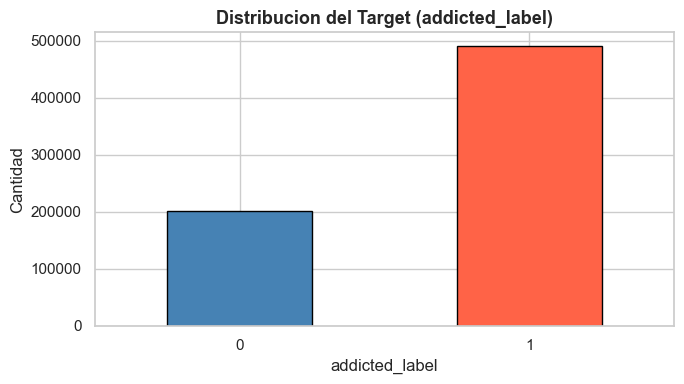

In [7]:
counts = train[TARGET].value_counts().reindex(CLASS_ORDER)
props  = train[TARGET].value_counts(normalize=True).reindex(CLASS_ORDER)
BASE   = train[TARGET].mean()

print(f"{'='*45}")
print("DISTRIBUCION DEL TARGET")
print(f"{'='*45}")
for cls in CLASS_ORDER:
    print(f"  addicted_label = {cls}: {counts[cls]:>9,}  ({props[cls]*100:.2f}%)")
print(f"{'='*45}")
print(f"  Ratio mayoritaria/minoritaria: {counts.max()/counts.min():.2f}x")
print(f"  Tasa base P(y=1):              {BASE:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot.bar(ax=ax, color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="black")
ax.set_title("Distribucion del Target (addicted_label)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cantidad")
ax.set_xlabel("addicted_label")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Valores Faltantes

Todas las variables predictoras tienen nulos, entre el 4% y el 19%. Antes de elegir una estrategia de
imputación conviene responder dos preguntas: **¿los valores faltan juntos?** (patrón estructurado) y
**¿el hecho de que un valor falte dice algo sobre el target?** Si la respuesta a la segunda es que no,
los indicadores de nulo no aportarán nada como features.

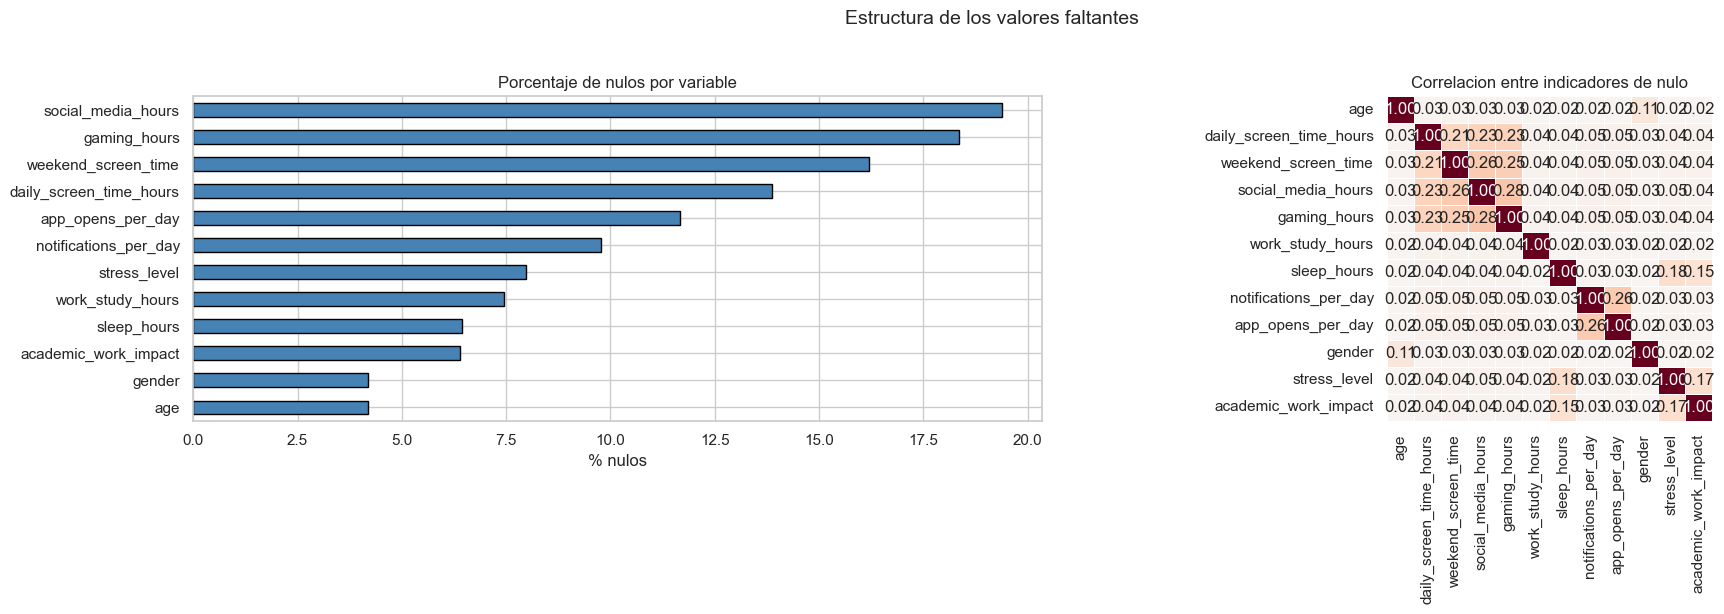

In [8]:
features = numericas + categoricas
na = train[features].isnull()

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
(na.mean() * 100).sort_values().plot.barh(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Porcentaje de nulos por variable")
axes[0].set_xlabel("% nulos")
sns.heatmap(na.astype(int).corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar=False, ax=axes[1])
axes[1].set_title("Correlacion entre indicadores de nulo")
plt.suptitle("Estructura de los valores faltantes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

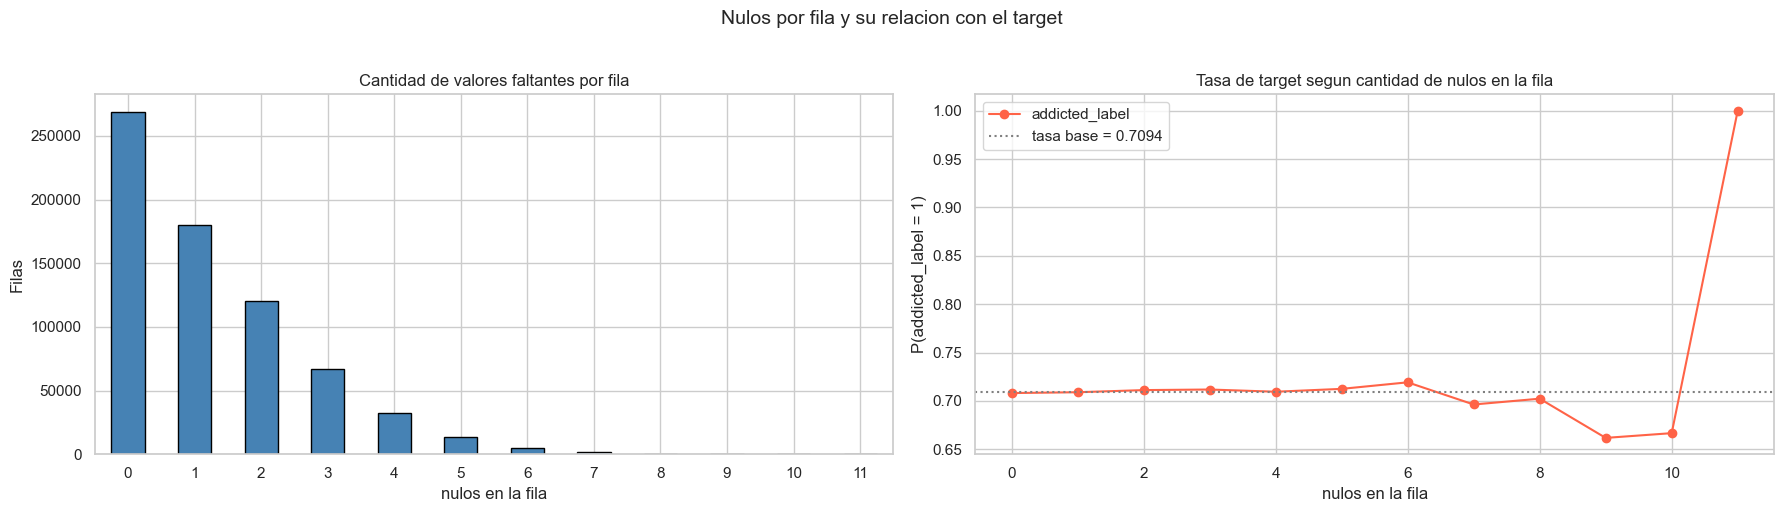

In [9]:
n_missing = na.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
n_missing.value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Cantidad de valores faltantes por fila")
axes[0].set_xlabel("nulos en la fila")
axes[0].set_ylabel("Filas")
axes[0].tick_params(axis="x", rotation=0)

train.groupby(n_missing)[TARGET].mean().plot(ax=axes[1], marker="o", color="tomato")
axes[1].axhline(BASE, color="gray", ls=":", lw=1.5, label=f"tasa base = {BASE:.4f}")
axes[1].set_title("Tasa de target segun cantidad de nulos en la fila")
axes[1].set_xlabel("nulos en la fila")
axes[1].set_ylabel("P(addicted_label = 1)")
axes[1].legend()
plt.suptitle("Nulos por fila y su relacion con el target", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Tasa de target segun si cada variable esta ausente u observada
filas = []
for c in features:
    m = na[c]
    t_miss, t_obs = train.loc[m, TARGET].mean(), train.loc[~m, TARGET].mean()
    filas.append({"variable": c,
                  "pct_null": round(m.mean() * 100, 2),
                  "tasa_missing": round(t_miss, 4),
                  "tasa_observado": round(t_obs, 4),
                  "delta": round(t_miss - t_obs, 4)})
resumen_na = pd.DataFrame(filas).sort_values("delta", key=abs, ascending=False)

print(f"Tasa base:               {BASE:.4f}")
print(f"Delta maximo (absoluto): {resumen_na['delta'].abs().max():.4f}")
resumen_na.reset_index(drop=True)

Tasa base:               0.7094
Delta maximo (absoluto): 0.0042


,variable,pct_null,tasa_missing,tasa_observado,delta
0,age,4.18,0.7134,0.7093,0.0042
1,sleep_hours,6.43,0.7134,0.7092,0.0042
2,app_opens_per_day,11.67,0.7128,0.7090,0.0038
3,daily_screen_time_hours,13.86,0.7113,0.7091,0.0022
4,weekend_screen_time,16.21,0.7107,0.7092,0.0015
5,work_study_hours,7.45,0.7106,0.7093,0.0013
6,gaming_hours,18.34,0.7105,0.7092,0.0013
7,notifications_per_day,9.78,0.7102,0.7093,0.0009
8,gender,4.20,0.7088,0.7095,-0.0007
9,stress_level,7.98,0.7090,0.7095,-0.0005


## 5. Variables Numéricas — Distribuciones

`age` es en realidad discreta (18 valores enteros distintos); el resto de las variables son continuas.

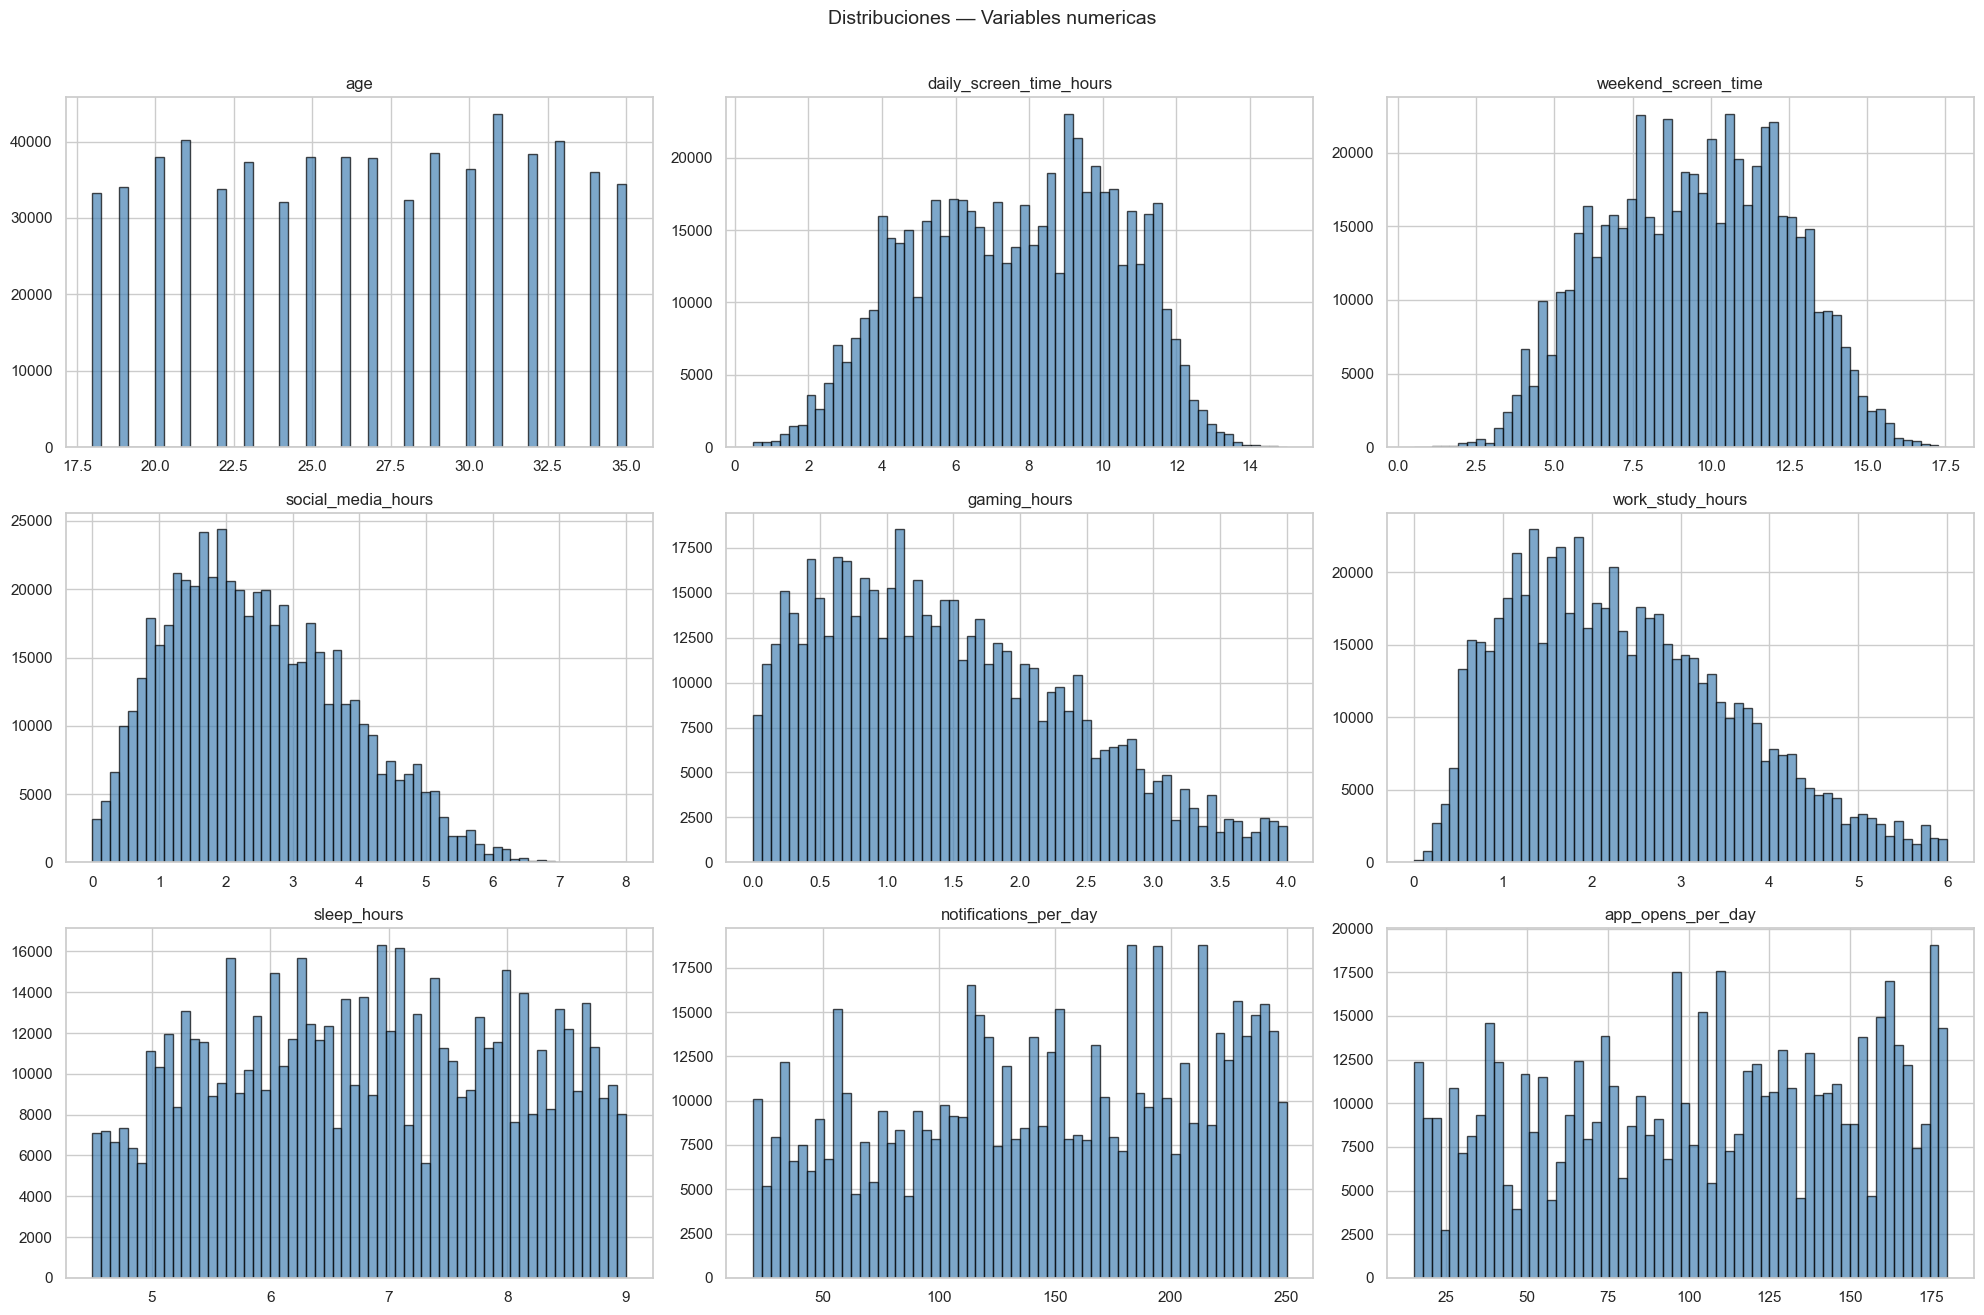

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(20, 13))
for ax, col in zip(axes.flat, numericas):
    train[col].hist(bins=60, ax=ax, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(col)
plt.suptitle("Distribuciones — Variables numericas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Variables Numéricas vs Target

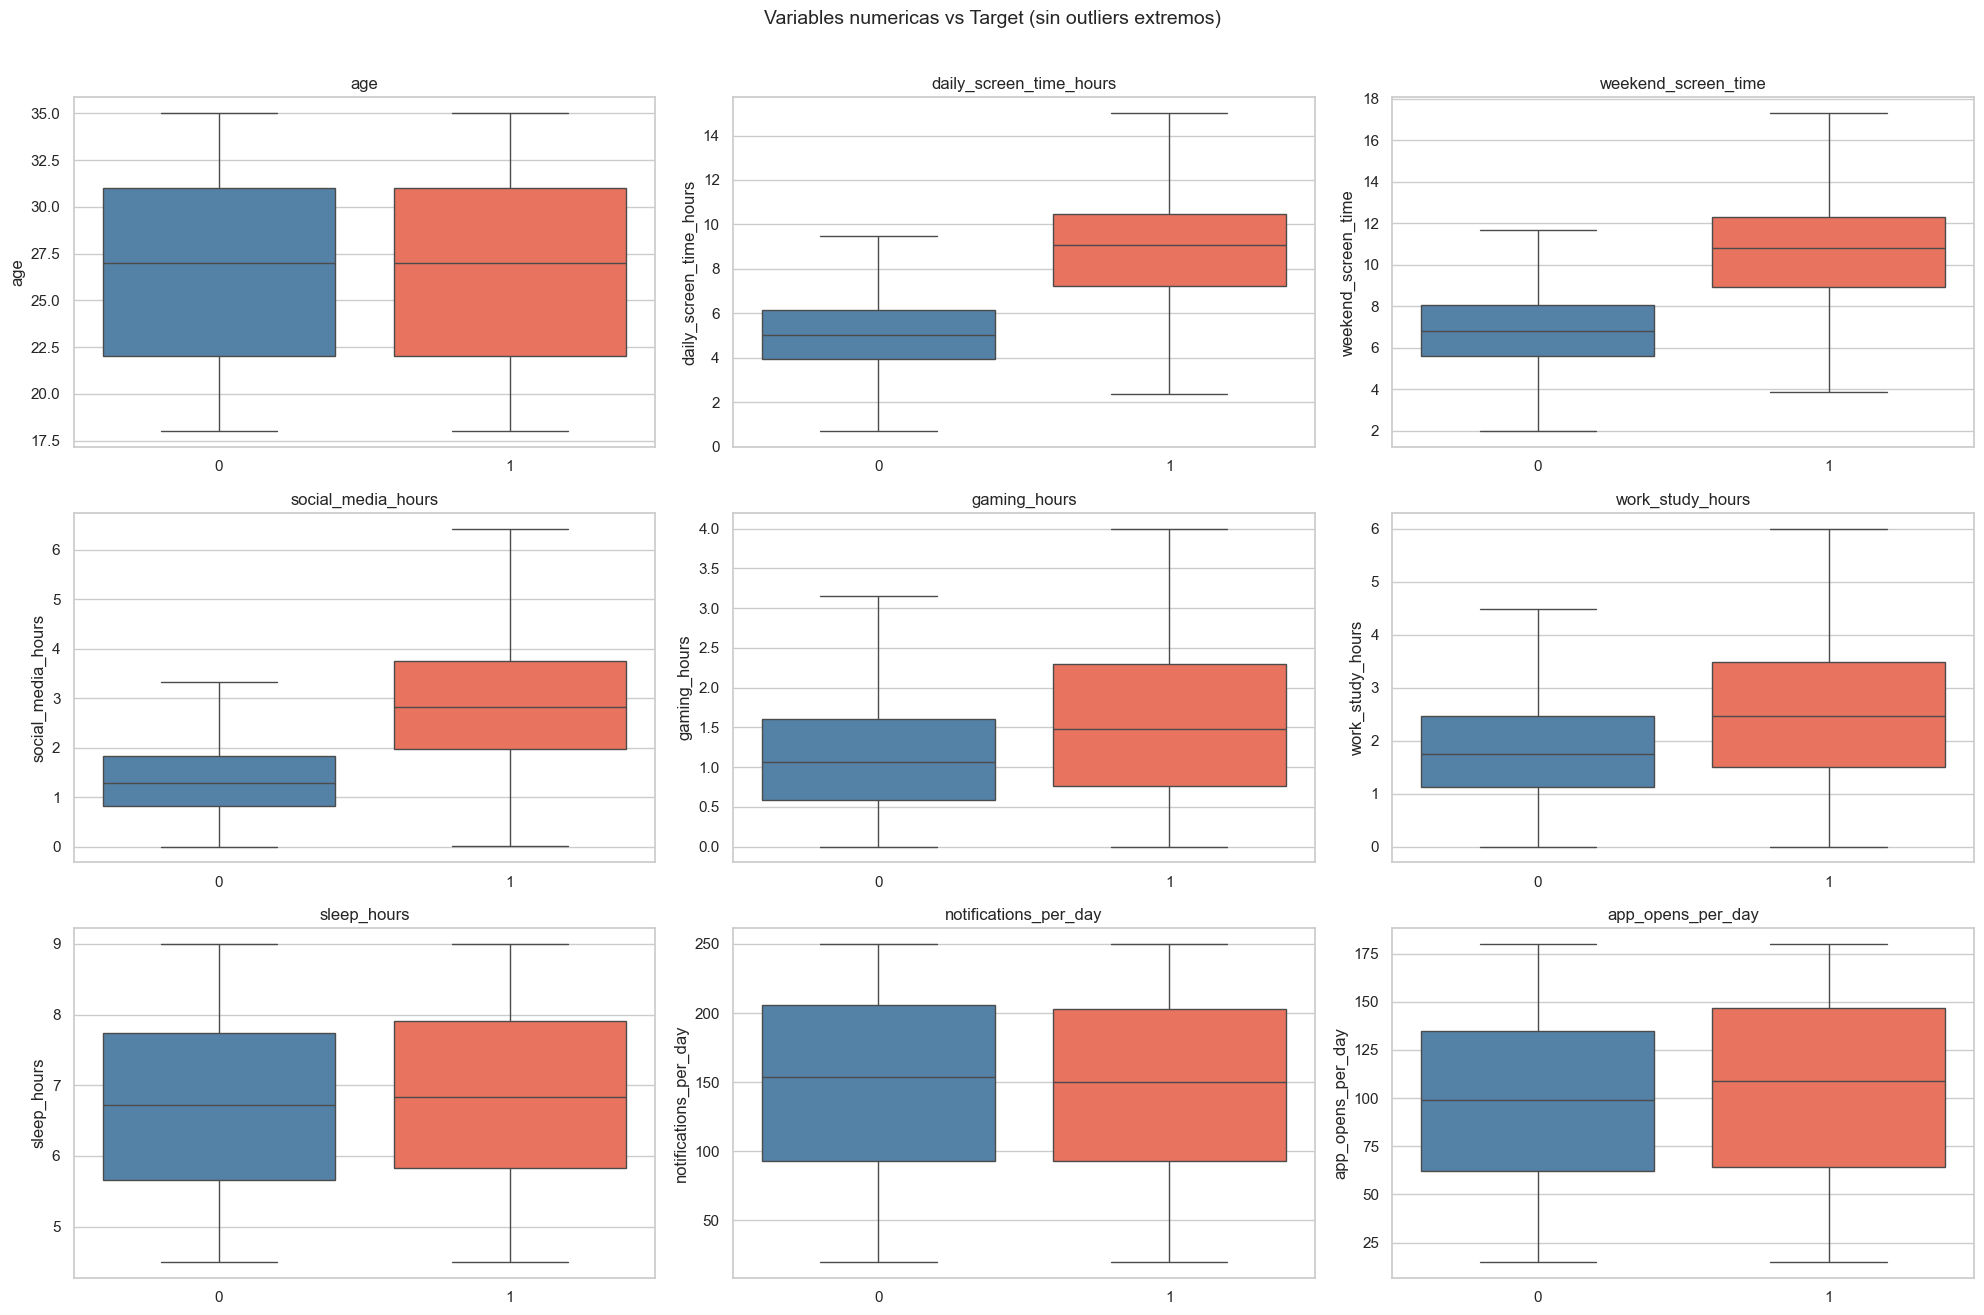

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(20, 13))
for ax, col in zip(axes.flat, numericas):
    sns.boxplot(data=train, x=TARGET, y=col, order=CLASS_ORDER, hue=TARGET,
                palette=PALETTE, legend=False, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Variables numericas vs Target (sin outliers extremos)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Variables Categóricas vs Target


gender:
          tasa   filas
gender                
Female  0.7038  221595
Male    0.7232  223662
Other   0.7010  217078

stress_level:
                tasa   filas
stress_level                
High          0.7114  220873
Low           0.7112  207783
Medium        0.7057  207565

academic_work_impact:
                        tasa   filas
academic_work_impact                
No                    0.7110  316579
Yes                   0.7079  330566


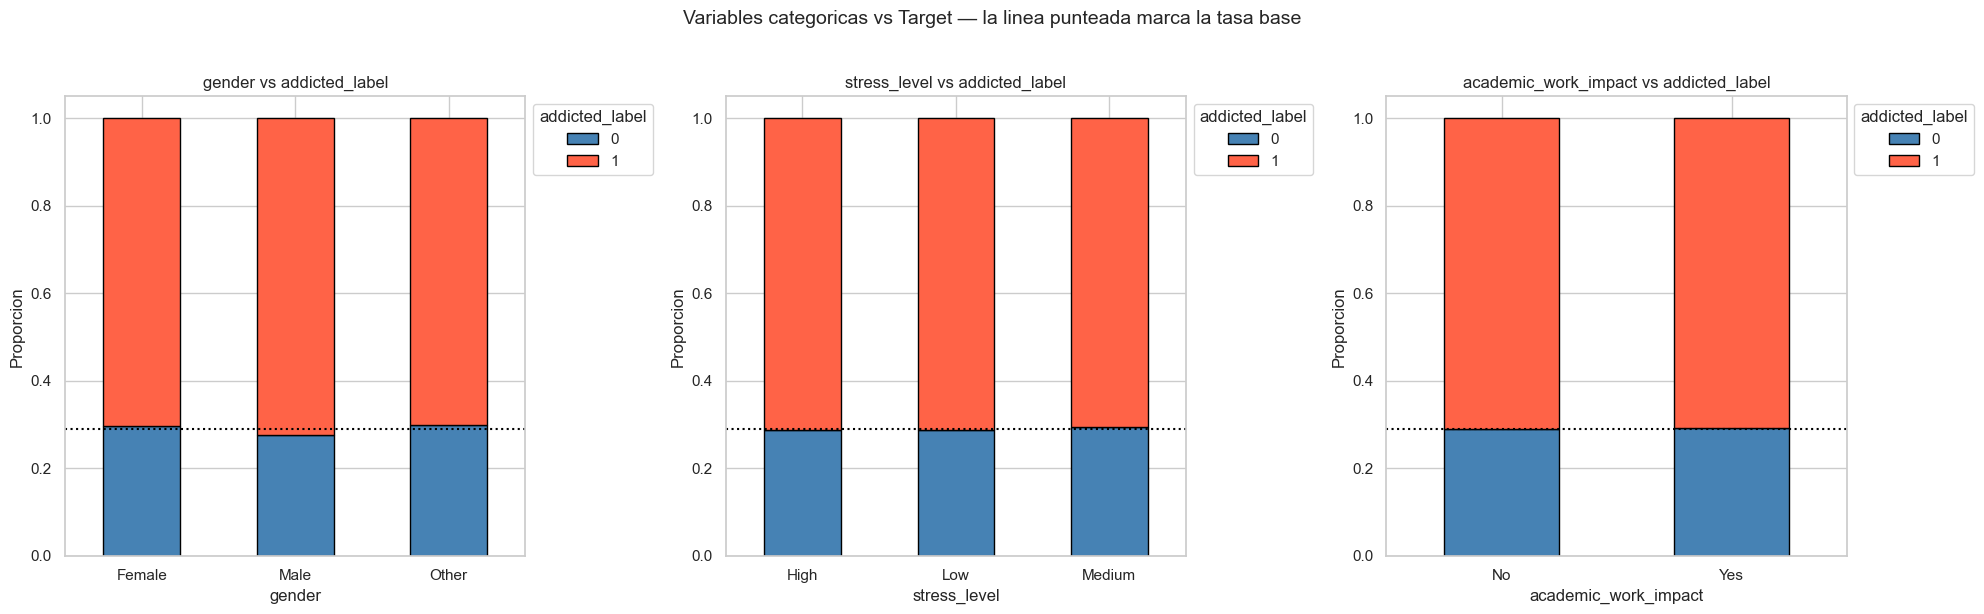

In [13]:
for c in categoricas:
    r = train.groupby(c)[TARGET].agg(tasa="mean", filas="size")
    print(f"\n{c}:")
    print(r.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes.flat, categoricas):
    props_c = (
        train.groupby(col)[TARGET]
             .value_counts(normalize=True)
             .unstack(fill_value=0)
             .reindex(columns=CLASS_ORDER, fill_value=0)
    )
    props_c.plot.bar(stacked=True, ax=ax,
                     color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="black")
    ax.axhline(1 - BASE, color="black", ls=":", lw=1.5)
    ax.set_title(f"{col} vs {TARGET}")
    ax.set_ylabel("Proporcion")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title=TARGET, bbox_to_anchor=(1.0, 1.0))
plt.suptitle("Variables categoricas vs Target — la linea punteada marca la tasa base",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Features Derivadas (patrones de uso)

Las horas crudas dominan la señal, pero no dicen **cómo** se reparte ese tiempo. Se construyen dos
grupos de variables derivadas: el **residual** de pantalla no atribuido a las actividades declaradas,
y un conjunto de **ratios** que normalizan cada actividad por el total de uso.

Filas con las 4 variables presentes:        421,427
Correlacion total vs suma de componentes:  0.8382
Filas con residual negativo:               0

Residual 'otro_uso' (horas de pantalla no atribuidas):
count    421427.000
mean          1.343
std           1.480
min           0.000
25%           0.460
50%           0.750
75%           1.460
max          11.530


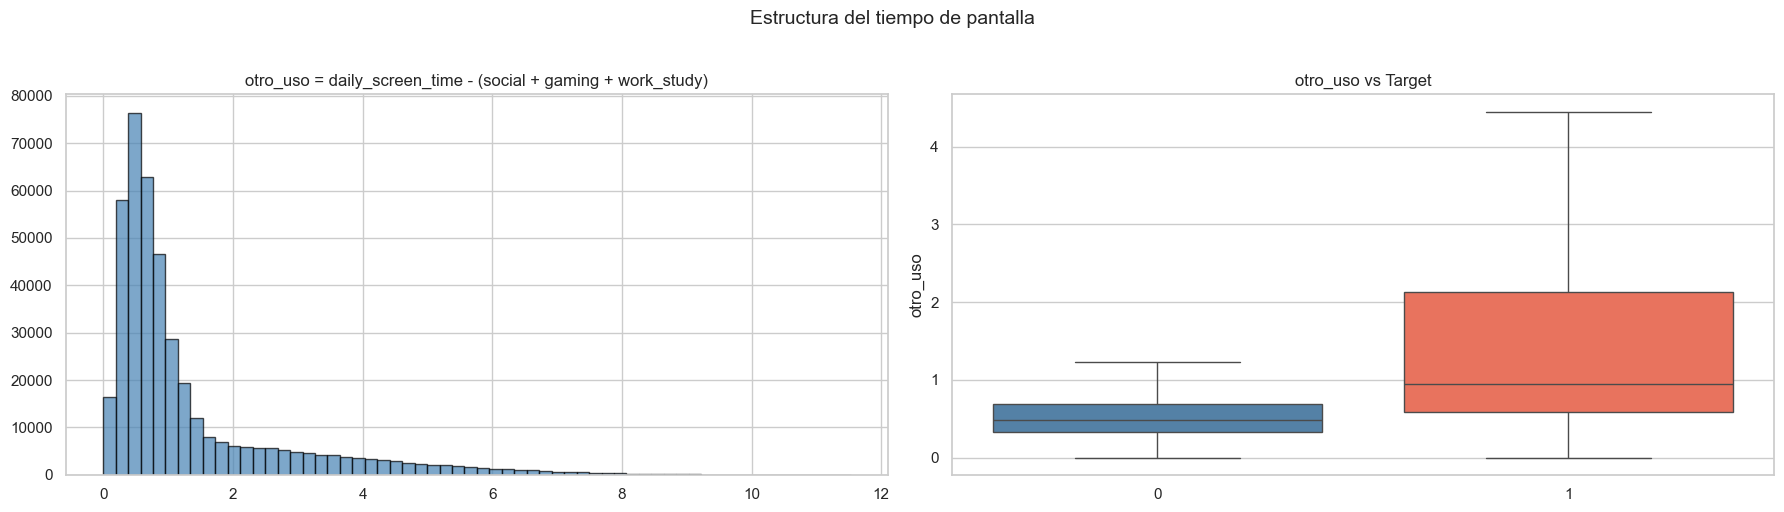

In [14]:
componentes = ["social_media_hours", "gaming_hours", "work_study_hours"]
train["otro_uso"] = train["daily_screen_time_hours"] - train[componentes].sum(axis=1)

completos = train.dropna(subset=["daily_screen_time_hours"] + componentes)
suma_comp = completos[componentes].sum(axis=1)
print(f"Filas con las 4 variables presentes:        {len(completos):,}")
print(f"Correlacion total vs suma de componentes:  "
      f"{completos['daily_screen_time_hours'].corr(suma_comp):.4f}")
print(f"Filas con residual negativo:               {(completos['otro_uso'] < 0).sum():,}")
print("\nResidual 'otro_uso' (horas de pantalla no atribuidas):")
print(completos["otro_uso"].describe().round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
completos["otro_uso"].hist(bins=60, ax=axes[0], color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("otro_uso = daily_screen_time - (social + gaming + work_study)")
sns.boxplot(data=completos, x=TARGET, y="otro_uso", order=CLASS_ORDER, hue=TARGET,
            palette=PALETTE, legend=False, showfliers=False, ax=axes[1])
axes[1].set_title("otro_uso vs Target")
axes[1].set_xlabel("")
plt.suptitle("Estructura del tiempo de pantalla", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

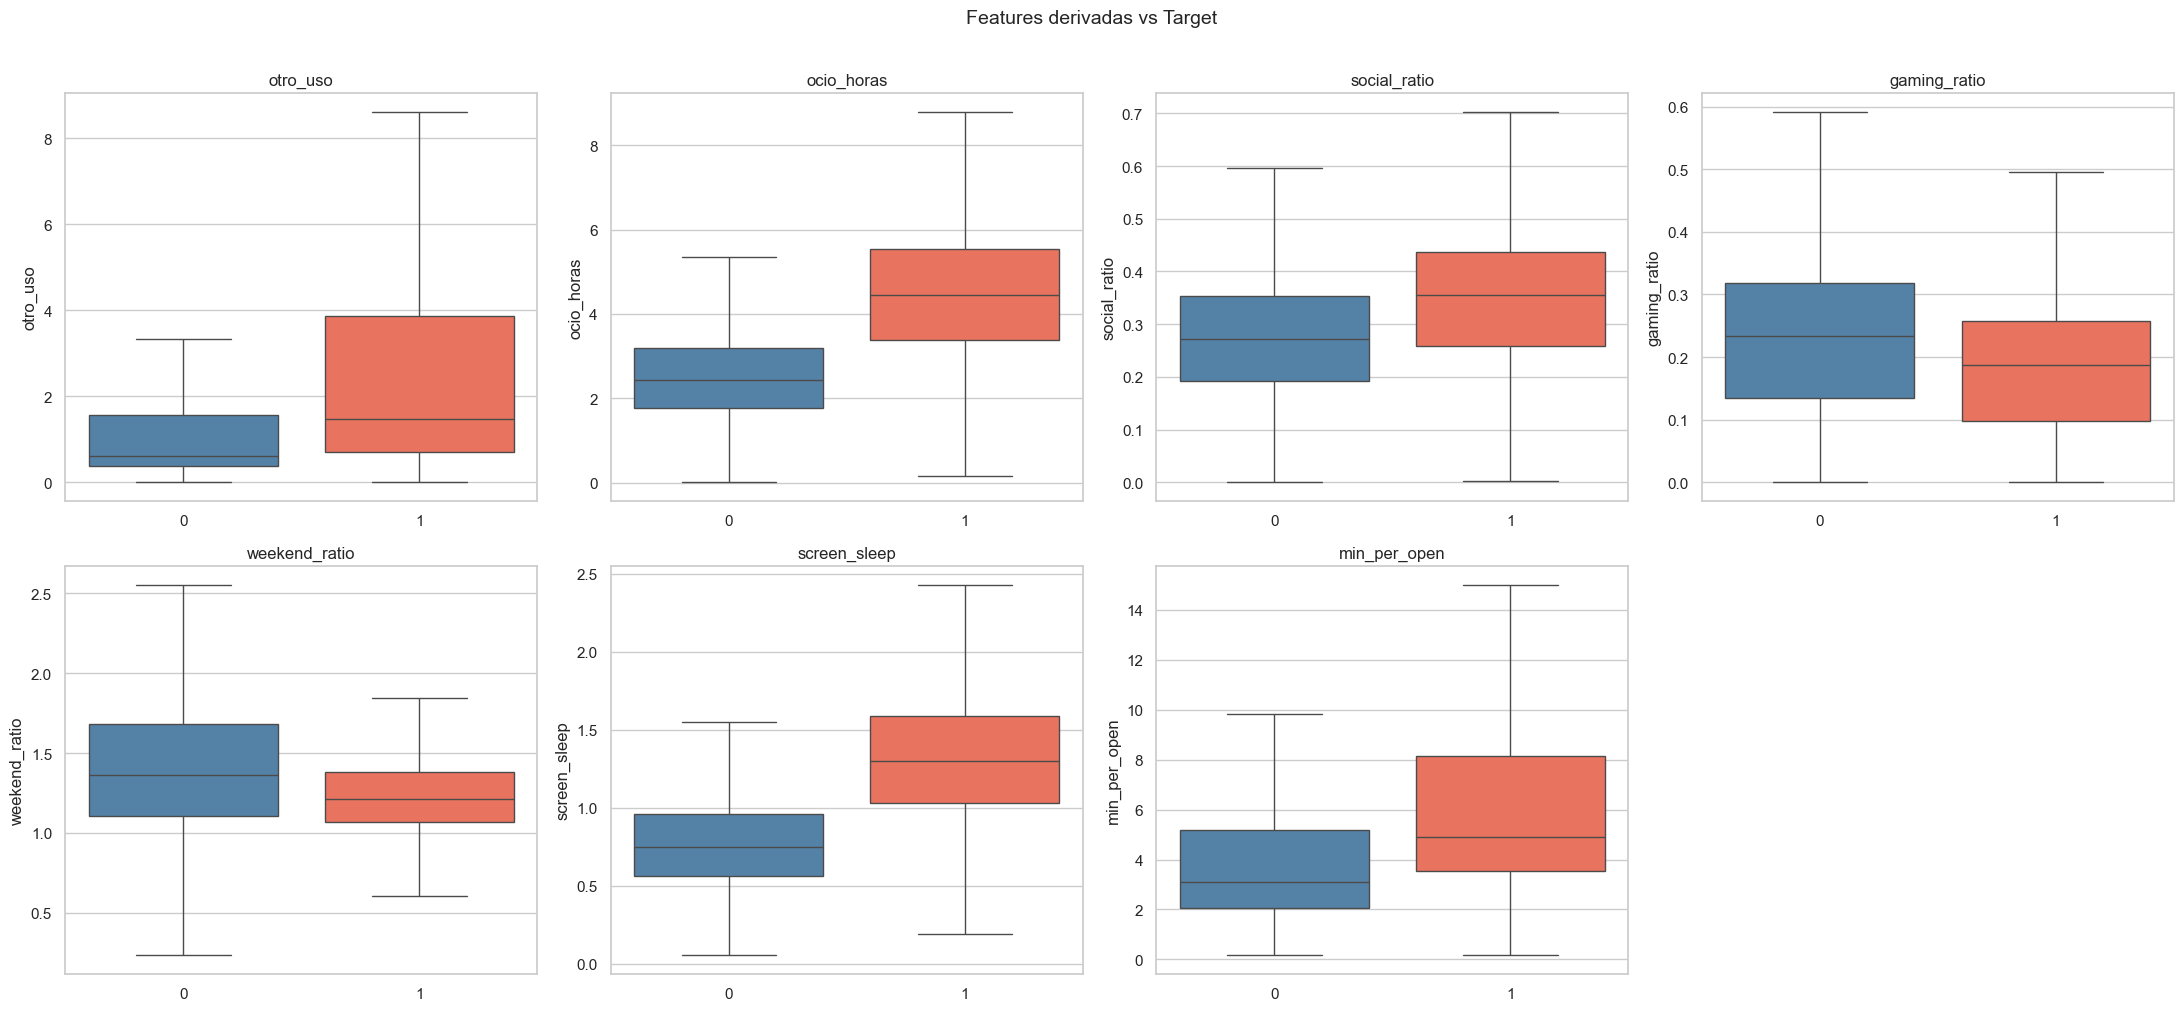

In [15]:
train["social_ratio"]  = train["social_media_hours"] / train["daily_screen_time_hours"]
train["gaming_ratio"]  = train["gaming_hours"] / train["daily_screen_time_hours"]
train["weekend_ratio"] = train["weekend_screen_time"] / train["daily_screen_time_hours"]
train["screen_sleep"]  = train["daily_screen_time_hours"] / train["sleep_hours"]
train["min_per_open"]  = train["daily_screen_time_hours"] * 60 / train["app_opens_per_day"]
train["ocio_horas"]    = train["social_media_hours"] + train["gaming_hours"]

derivadas = ["otro_uso", "ocio_horas", "social_ratio", "gaming_ratio",
             "weekend_ratio", "screen_sleep", "min_per_open"]
train[derivadas] = train[derivadas].replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, col in zip(axes.flat, derivadas):
    sns.boxplot(data=train, x=TARGET, y=col, order=CLASS_ORDER, hue=TARGET,
                palette=PALETTE, legend=False, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
axes.flat[-1].set_visible(False)
plt.suptitle("Features derivadas vs Target", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Correlaciones

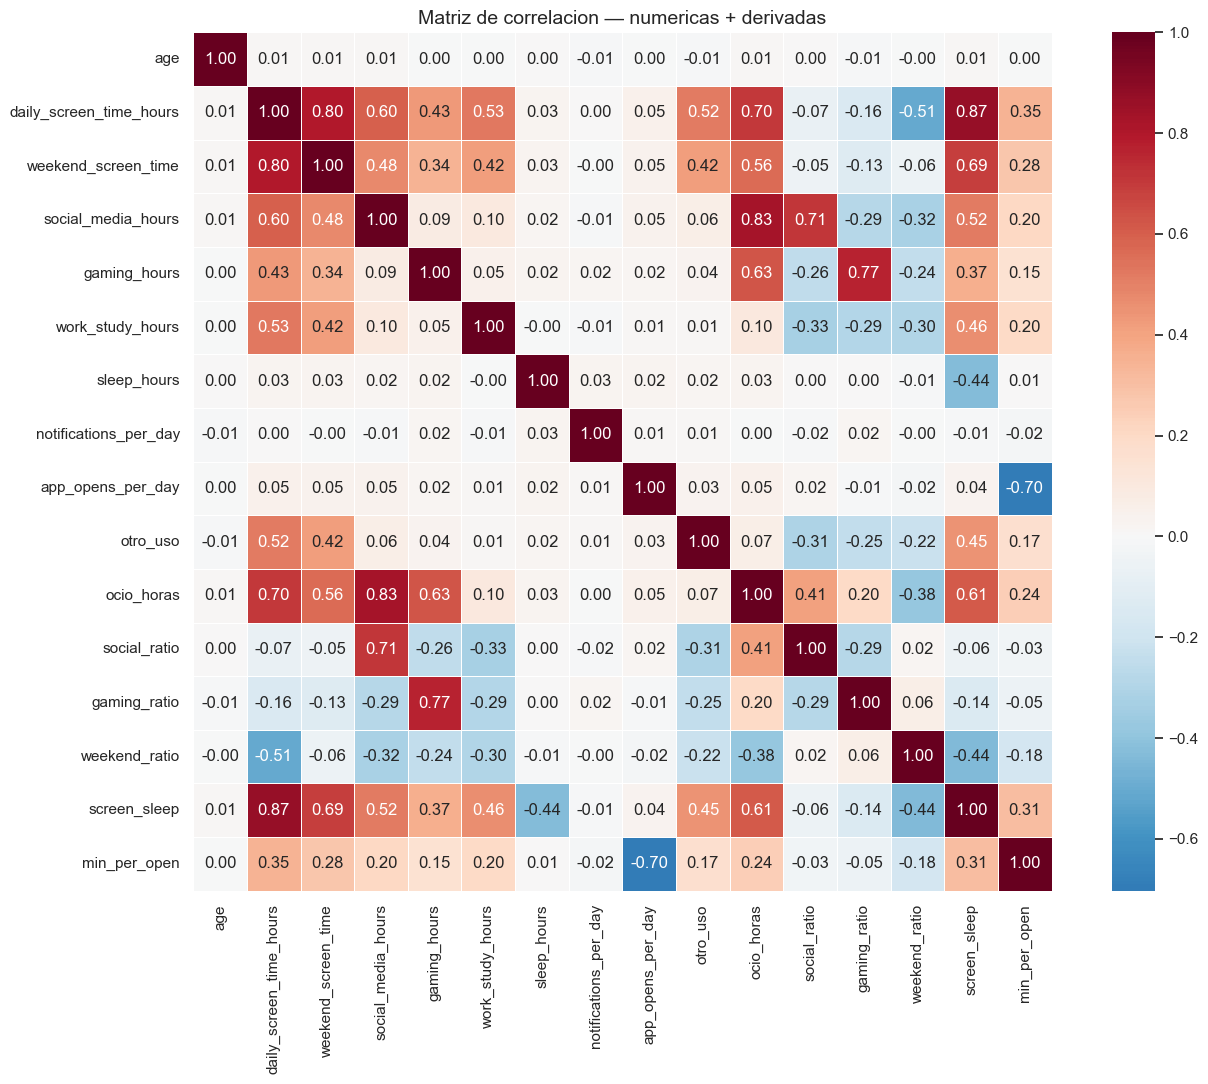

In [16]:
cols_corr = numericas + derivadas
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(train[cols_corr].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlacion — numericas + derivadas", fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
corr_t = (train[cols_corr + [TARGET]].corr()[TARGET]
          .drop(TARGET).sort_values(key=abs, ascending=False))
print("Correlacion con el target (ordenada por magnitud):")
print(corr_t.round(4).to_string())

Correlacion con el target (ordenada por magnitud):
daily_screen_time_hours    0.6114
weekend_screen_time        0.5899
social_media_hours         0.5324
ocio_horas                 0.5309
screen_sleep               0.5217
otro_uso                   0.2879
work_study_hours           0.2514
social_ratio               0.2411
weekend_ratio             -0.2105
gaming_hours               0.2053
gaming_ratio              -0.1994
min_per_open               0.1934
app_opens_per_day          0.0635
sleep_hours                0.0425
notifications_per_day     -0.0116
age                        0.0040


## 10. Conclusiones

- **Dataset grande y limpio en estructura**: 691.369 filas × 14 columnas, sin duplicados; 9 numéricas,
  3 categóricas y el target. El test tiene 296.302 filas.
- **Target desbalanceado 71/29**: `addicted_label` = 1 en el 70,94 % de los casos (ratio 2,44x). Como
  la métrica es ROC AUC no hace falta rebalancear, pero sí estratificar los folds de validación.
- **Nulos masivos pero no informativos**: entre 4,18 % (`age`) y 19,38 % (`social_media_hours`) en
  todas las predictoras. Los indicadores de nulo no correlacionan entre sí y la tasa de target apenas
  se mueve según si el valor falta o no (delta máximo **0,0042** contra una tasa base de 0,7094). Es
  decir, **MCAR**: los missing indicators no van a aportar y conviene dejar que el modelo maneje los
  NaN de forma nativa (LightGBM / XGBoost / CatBoost) antes que imputar.
- **`daily_screen_time_hours` domina la señal**: correlación 0,611 con el target y **AUC univariada de
  0,890** ella sola — ese es el piso que cualquier modelo tiene que superar. La media es de 8,71 h en
  los casos positivos contra 5,04 h en los negativos.
- **El bloque de pantalla es redundante**: `weekend_screen_time` (corr 0,590, AUC 0,881) y
  `social_media_hours` (0,532) miden casi lo mismo — `daily` y `weekend` correlacionan 0,800 entre sí.
  Aportan poco por encima de la variable principal.
- **Cuatro variables sin señal lineal**: `app_opens_per_day` (0,064), `sleep_hours` (0,043),
  `notifications_per_day` (−0,012) y `age` (0,004). Candidatas a descartar, o a rescatar sólo si
  aparecen vía interacciones.
- **Categóricas casi inertes**: la tasa de target por nivel se mueve entre 0,701 y 0,723; la mayor
  diferencia es `gender` (Male 0,7232 vs Other 0,7010). `stress_level` y `academic_work_impact` son
  planas frente a la tasa base.
- **El tiempo de pantalla se descompone de forma consistente**: `daily_screen_time_hours` es siempre
  ≥ `social_media + gaming + work_study` (residual mínimo 0,00 en las 421.427 filas completas, mediana
  0,75 h, sin un solo caso negativo). El residual `otro_uso` es la derivada más útil del notebook
  (corr 0,288), por encima incluso de `work_study_hours`.
- **Los ratios no le ganan a las horas crudas**: los mejores son `ocio_horas` (0,531) y `screen_sleep`
  (0,522), pero ninguno supera a `daily_screen_time_hours` (0,611). Normalizar por el total borra
  justamente la magnitud que discrimina.
- **Próximo paso**: baseline de gradient boosting sobre las features crudas más `otro_uso`, con NaN
  nativos y CV estratificada, para medir si las derivadas aportan algo por encima del set base.